<a href="https://colab.research.google.com/github/matheus-cmc/atividades_IA_industrial/blob/main/Atividade_3_Desafio_Previs%C3%A3o_de_atrasos_de_aeronaves.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from xgboost import XGBClassifier
import joblib
import warnings
warnings.filterwarnings("ignore")
import seaborn as sns
import matplotlib.pyplot as plt

📥 Lendo arquivo CSV...
✅ Arquivo lido com separador ','.

📊 Dimensões do conjunto de dados: (120, 7)

🔎 Colunas disponíveis:
['airline', 'origin', 'destination', 'departure_hour', 'day_of_week', 'weather', 'delayed']

🔍 Verificando a coluna 'delayed':
delayed
0    68
1    52
Name: count, dtype: int64
✅ A coluna 'delayed' já é binária (0 = sem atraso, 1 = com atraso).

📊 Distribuição da variável alvo:
   atraso  proporcao
0       0   0.566667
1       1   0.433333
✅ Há pelo menos duas classes. Podemos prosseguir para modelagem.

🔧 Criando variáveis dummies para colunas categóricas...

✅ Dados prontos para modelagem!
📘 Treino: (84, 19) | 📗 Validação: (18, 19) | 📙 Teste: (18, 19)
✅ Padronização concluída.

📊 Desempenho do Modelo Base (Regressão Logística):
Accuracy:  1.0000
Precisão:  1.0000
Recall:    1.0000
F1-score:  1.0000

📊 Desempenho do XGBoost (inicial):
Accuracy:  1.0000
Precisão:  1.0000
Recall:    1.0000
F1-score:  1.0000

🔍 Iniciando busca pelos melhores hiperparâmetros...

✅ M

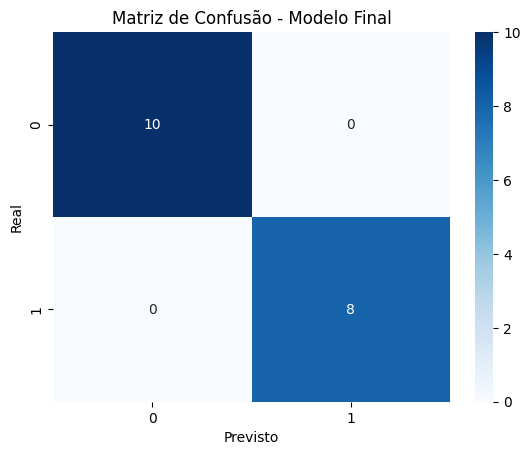


🔮 Inferência em 5 amostras aleatórias:
Previsões (0 = sem atraso, 1 = atraso): [1 0 0 0 1]

💾 Modelo salvo como 'modelo_previsao_atrasos.pkl'.


In [6]:
# =========================================================
# 📂 1. Carregamento dos dados
# =========================================================
print("📥 Lendo arquivo CSV...")
filepath = '/content/flights_delays_120 1.csv'  # ajuste conforme o nome do arquivo
try:
    dados = pd.read_csv(filepath, sep=',', encoding='utf-8')
    print("✅ Arquivo lido com separador ','.")
except Exception:
    dados = pd.read_csv(filepath, sep=';', encoding='latin1')
    print("✅ Arquivo lido com separador ';' e encoding 'latin1'.")

print(f"\n📊 Dimensões do conjunto de dados: {dados.shape}")
print("\n🔎 Colunas disponíveis:")
print(dados.columns.tolist())

# =========================================================
# 🏷️ 2. Criação da variável alvo
# =========================================================
print("\n🔍 Verificando a coluna 'delayed':")
print(dados["delayed"].value_counts())

# Se 'delayed' já for binário, mantém; caso contrário, define atraso > 15 min
if dados["delayed"].dropna().isin([0, 1]).all():
    dados["atraso"] = dados["delayed"]
    print("✅ A coluna 'delayed' já é binária (0 = sem atraso, 1 = com atraso).")
else:
    dados["atraso"] = (dados["delayed"] > 15).astype(int)
    print("✅ A coluna 'delayed' representa minutos — atraso considerado > 15 minutos.")

# Distribuição da variável alvo
dist = dados["atraso"].value_counts(normalize=True).rename_axis("atraso").reset_index(name="proporcao")
print("\n📊 Distribuição da variável alvo:")
print(dist)

if dados["atraso"].nunique() < 2:
    print("\n⚠️ Só existe uma classe na variável 'atraso'. O modelo não pode ser treinado assim.")
else:
    print("✅ Há pelo menos duas classes. Podemos prosseguir para modelagem.")

# =========================================================
# 🧹 3. Preparação dos dados
# =========================================================
print("\n🔧 Criando variáveis dummies para colunas categóricas...")
colunas_categoricas = dados.select_dtypes(include=['object']).columns
dados = pd.get_dummies(dados, columns=colunas_categoricas, drop_first=True)

# Separação entre features e target
X = dados.drop("atraso", axis=1)
y = dados["atraso"]

# Divisão em treino, validação e teste
X_treino, X_temp, y_treino, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_valid, X_teste, y_valid, y_teste = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"\n✅ Dados prontos para modelagem!")
print(f"📘 Treino: {X_treino.shape} | 📗 Validação: {X_valid.shape} | 📙 Teste: {X_teste.shape}")

# Padronização das features
scaler = StandardScaler()
X_treino = scaler.fit_transform(X_treino)
X_valid = scaler.transform(X_valid)
X_teste = scaler.transform(X_teste)
print("✅ Padronização concluída.")

# =========================================================
# ⚙️ 4. Modelo Base - Regressão Logística
# =========================================================
modelo_base = LogisticRegression(max_iter=500, random_state=42)
modelo_base.fit(X_treino, y_treino)
pred_base = modelo_base.predict(X_valid)

print("\n📊 Desempenho do Modelo Base (Regressão Logística):")
print(f"Accuracy:  {accuracy_score(y_valid, pred_base):.4f}")
print(f"Precisão:  {precision_score(y_valid, pred_base):.4f}")
print(f"Recall:    {recall_score(y_valid, pred_base):.4f}")
print(f"F1-score:  {f1_score(y_valid, pred_base):.4f}")

# =========================================================
# 🌲 5. Modelo Avançado - XGBoost
# =========================================================
!pip install -q xgboost

modelo_xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8
)

modelo_xgb.fit(X_treino, y_treino, eval_set=[(X_valid, y_valid)], verbose=False)
pred_xgb = modelo_xgb.predict(X_valid)

print("\n📊 Desempenho do XGBoost (inicial):")
print(f"Accuracy:  {accuracy_score(y_valid, pred_xgb):.4f}")
print(f"Precisão:  {precision_score(y_valid, pred_xgb):.4f}")
print(f"Recall:    {recall_score(y_valid, pred_xgb):.4f}")
print(f"F1-score:  {f1_score(y_valid, pred_xgb):.4f}")

# =========================================================
# 🔧 6. Ajuste de Hiperparâmetros (GridSearch)
# =========================================================
parametros = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1],
}

grid = GridSearchCV(
    estimator=XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid=parametros,
    scoring='f1',
    cv=3,
    verbose=0,
    n_jobs=-1
)

print("\n🔍 Iniciando busca pelos melhores hiperparâmetros...")
grid.fit(X_treino, y_treino)

print("\n✅ Melhor combinação encontrada:")
print(grid.best_params_)

modelo_final = grid.best_estimator_
pred_final = modelo_final.predict(X_teste)

# =========================================================
# 📈 7. Avaliação Final
# =========================================================
print("\n📊 Desempenho final do modelo no conjunto de teste:")
print(f"Accuracy:  {accuracy_score(y_teste, pred_final):.4f}")
print(f"Precisão:  {precision_score(y_teste, pred_final):.4f}")
print(f"Recall:    {recall_score(y_teste, pred_final):.4f}")
print(f"F1-score:  {f1_score(y_teste, pred_final):.4f}")

print("\n📋 Relatório de Classificação:")
print(classification_report(y_teste, pred_final))

# Matriz de Confusão
matriz = confusion_matrix(y_teste, pred_final)
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusão - Modelo Final")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.show()

# =========================================================
# 🔮 8. Inferência com Novos Dados
# =========================================================
print("\n🔮 Inferência em 5 amostras aleatórias:")
amostras = X_teste[:5]
preds = modelo_final.predict(amostras)
print("Previsões (0 = sem atraso, 1 = atraso):", preds)

# =========================================================
# 💾 9. Salvamento do Modelo
# =========================================================
joblib.dump(modelo_final, "modelo_previsao_atrasos.pkl")
print("\n💾 Modelo salvo como 'modelo_previsao_atrasos.pkl'.")